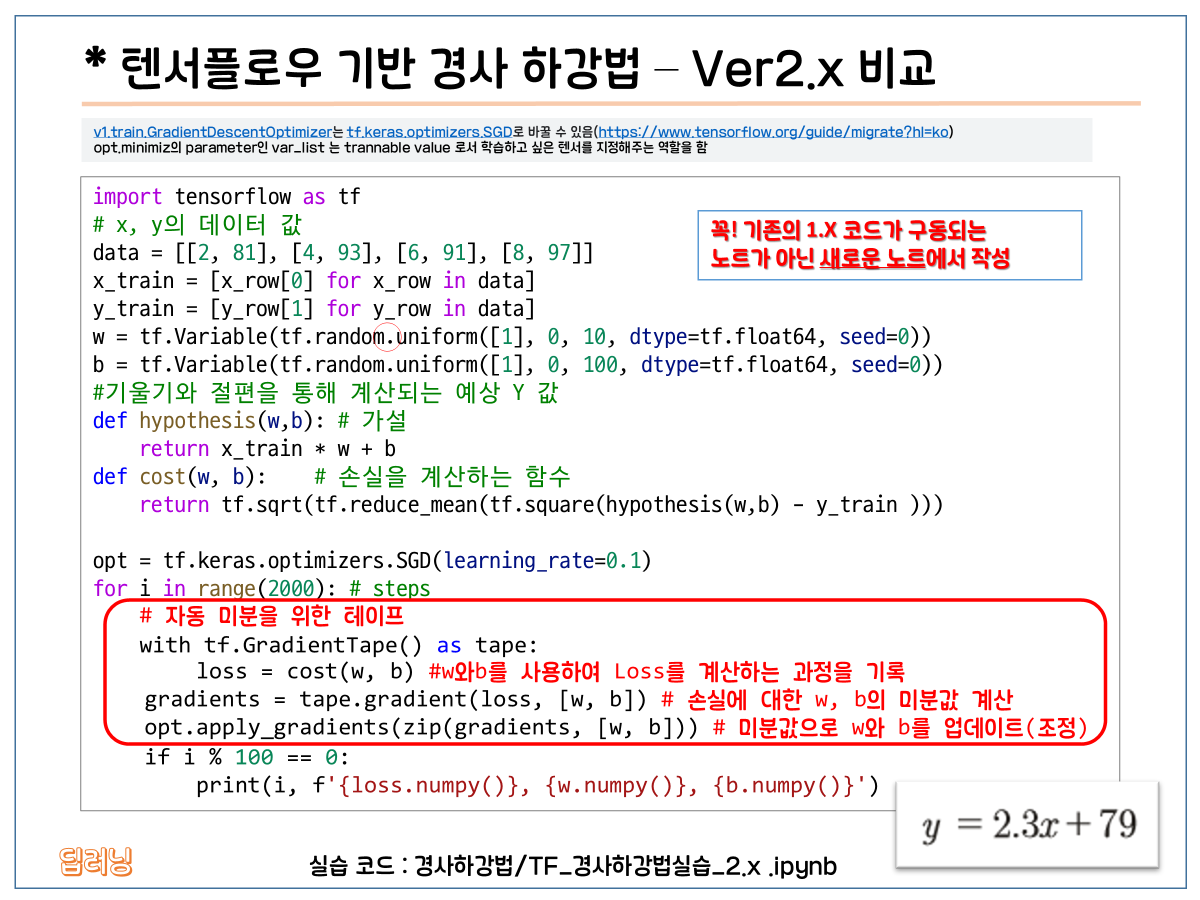

In [5]:
import tensorflow as tf

data = [[2, 81], [4, 93], [6, 91], [8, 97]]
x_train = [x_row[0] for x_row in data]
y_train = [y_row[1] for y_row in data]

w = tf.Variable(tf.random.uniform([1], 0, 10, dtype = tf.float64, seed = 0)) # 32비트 실수보다 더 정밀하게 표현 가능한 실수
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype = tf.float64, seed = 0))

def hypothesis(w, b):
    return x_train * w + b

def cost(w, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w, b) - y_train)))

opt = tf.keras.optimizers.SGD(learning_rate = 0.1)

for i in range(2001):
    with tf.GradientTape() as tape: # tape 객체
        loss = cost(w, b)
    gradients = tape.gradient(loss, [w, b])
    opt.apply_gradients(zip(gradients, [w, b]))

    if i % 100 == 0:
        print(i, f'{loss.numpy()}, {w.numpy()}, {b.numpy()}') # loss, w, b = tensor -> .numpy()

0 23.594414678873363, [7.26658168], [34.97659559]
100 16.496936306948616, [8.96034114], [39.25393244]
200 14.93016994405975, [8.30618821], [43.15763742]
300 13.376146857697513, [7.65470757], [47.04539527]
400 11.839709853630714, [7.00693394], [50.91103126]
500 10.328351329129674, [6.36448561], [54.74488811]
600 8.854129580405052, [5.73000909], [58.53117265]
700 7.437232142702615, [5.10804688], [62.24277713]
800 6.112442545167153, [4.50675817], [65.83101102]
900 4.938951829195666, [3.94111729], [69.20651386]
1000 4.004663376040696, [3.4370498], [72.21457306]
1100 3.389173653634497, [3.02915532], [74.64871287]
1200 3.07529760818053, [2.73924035], [76.37880147]
1300 2.9481815270292393, [2.55548701], [77.47536281]
1400 2.903228924178975, [2.44644257], [78.12609337]
1500 2.8882275000834152, [2.38350081], [78.50170287]
1600 2.8833247484485223, [2.34752831], [78.71637138]
1700 2.8817336325274225, [2.32703739], [78.8386524]
1800 2.8812184436892725, [2.31537788], [78.9082314]
1900 2.88105175459

**Q.** 지난 주에 MSE를 모델 학습에 주로 사용하고 RMSE는 결과 해석에 자주 사용한다고 들은 것 같은데요, 오늘 텐서플로우 실습 코드에서는 오차로 RMSE를 사용하는 특별한 이유가 있는지 궁금합니다

**A.** 특별한 이유는 없습니다.^^ 실제 케라스 모델링에서는 MSE를 사용하는데 워낙 작은 데이터고 오차가 명확하다보니 오차를 확대할 필요없이 같은 단위를 사용한다고 보시면 됩니다~

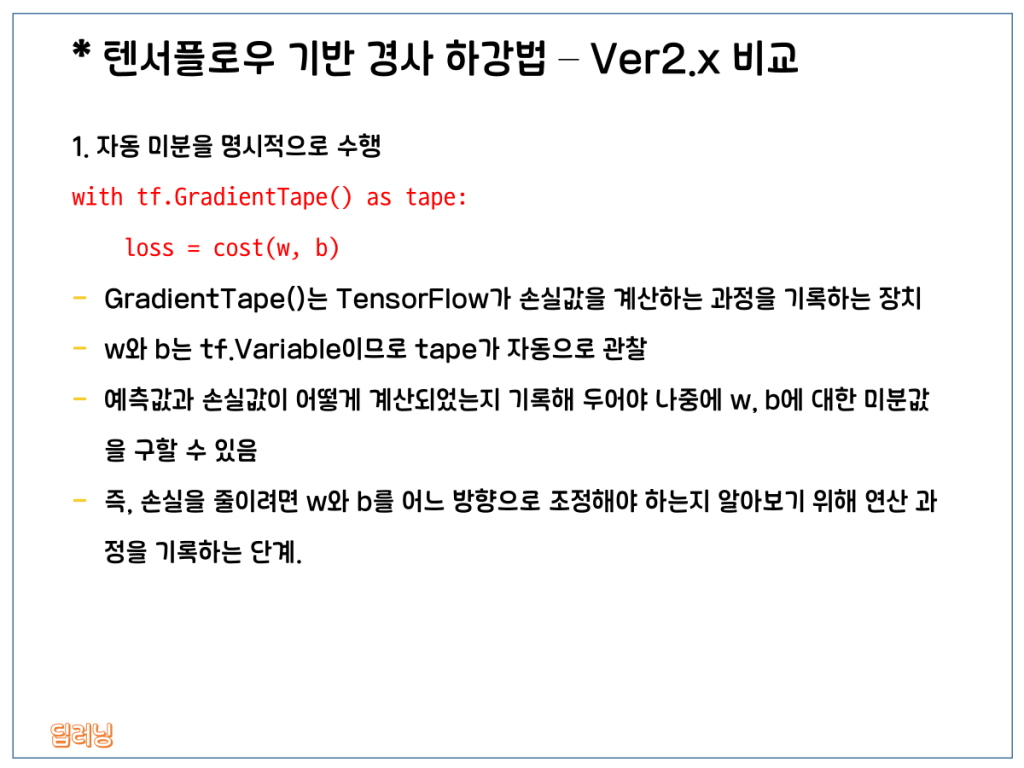

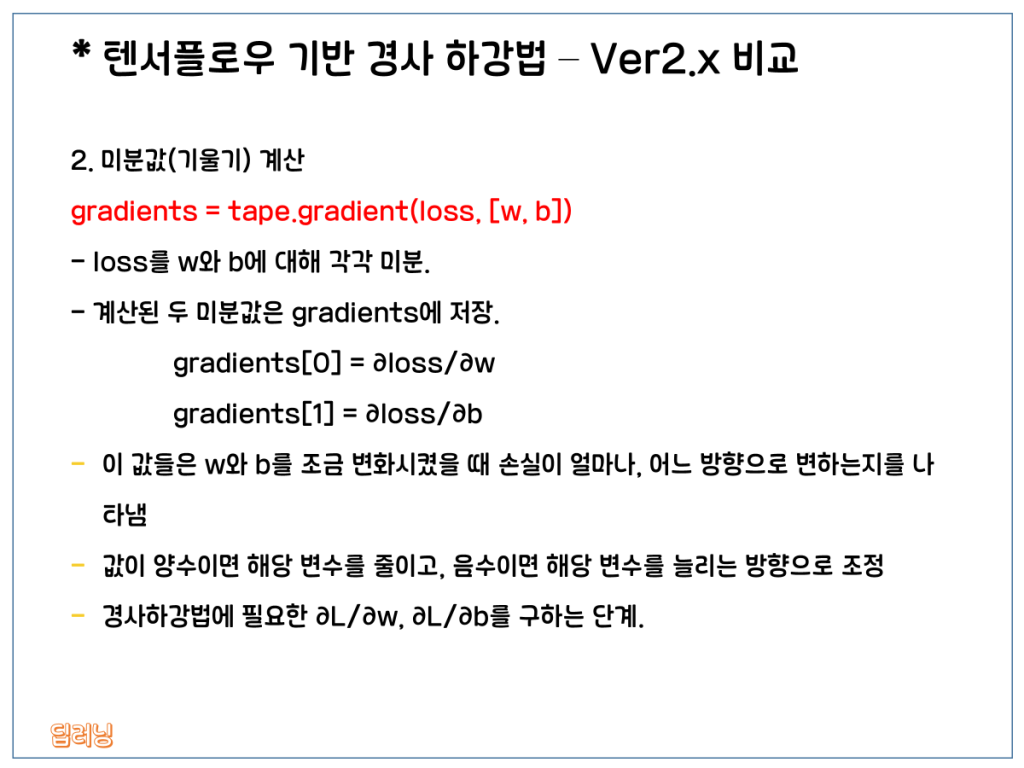

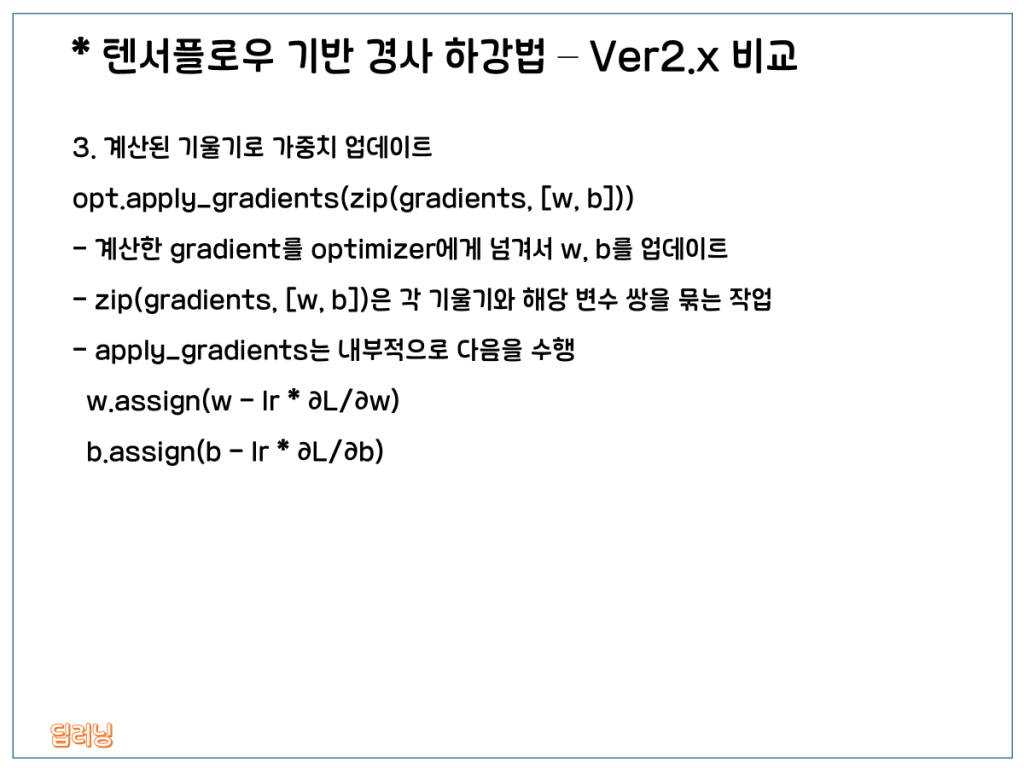

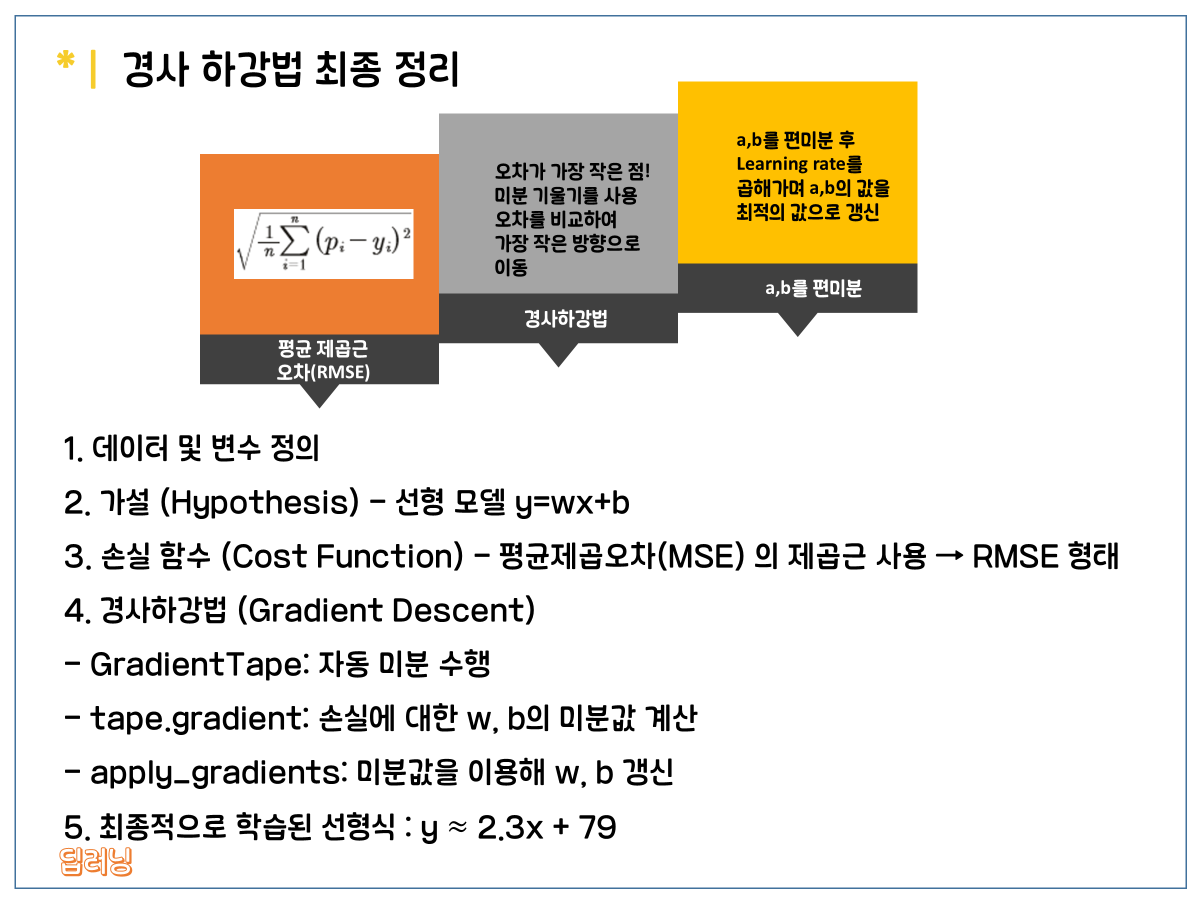

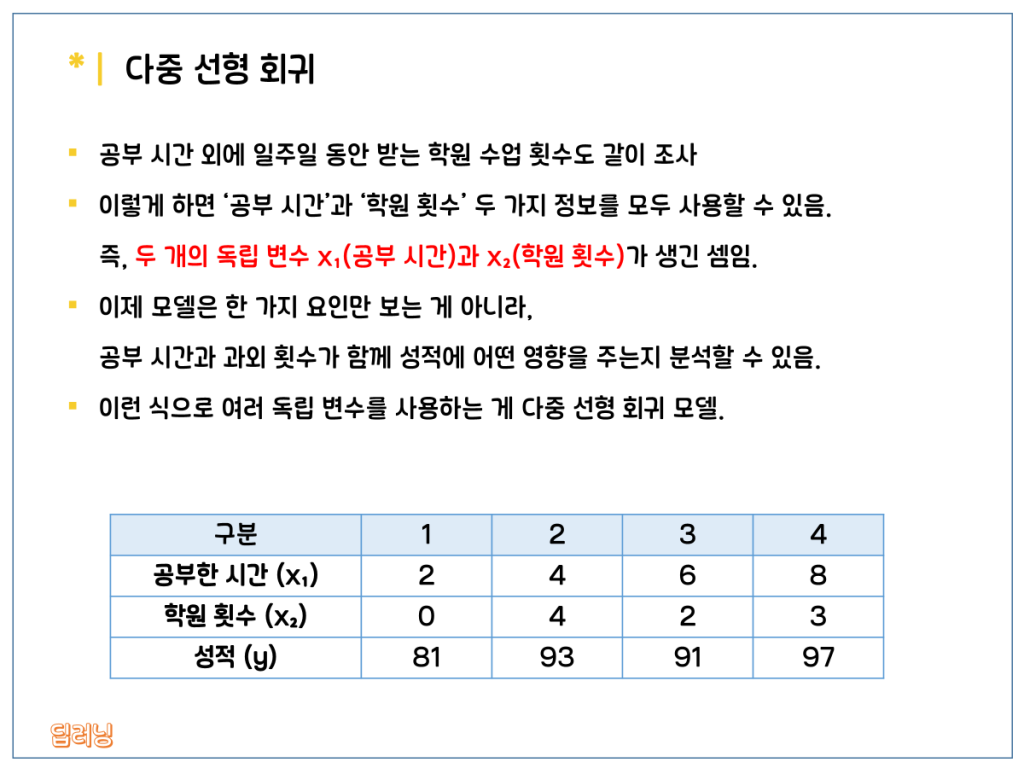

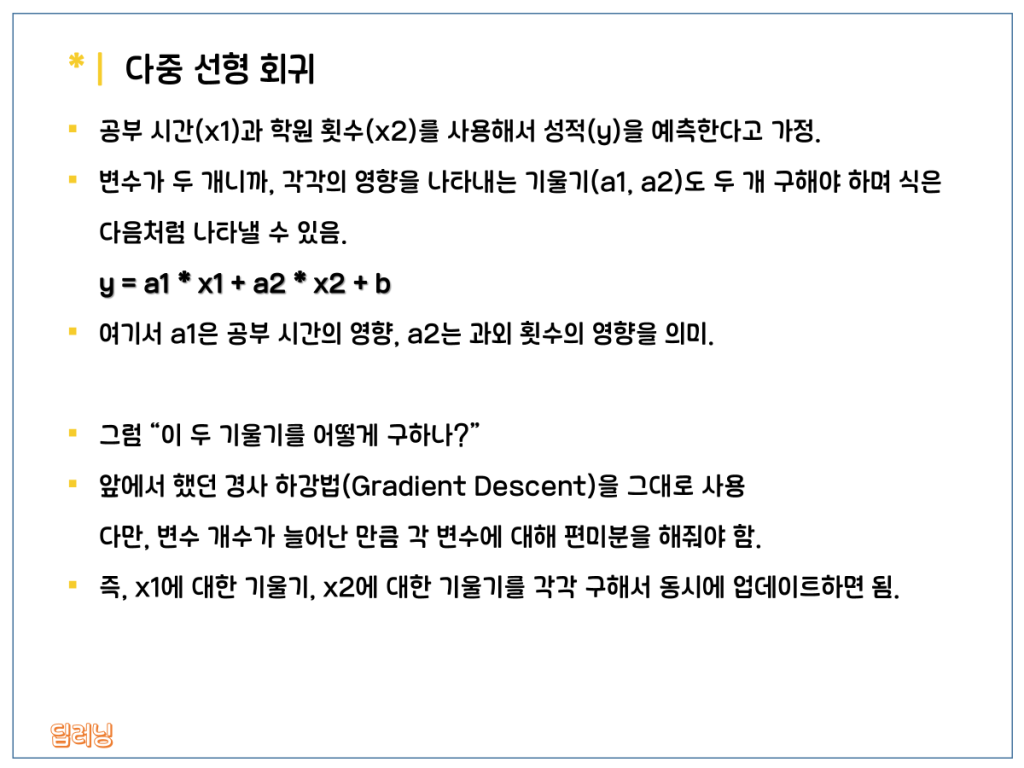

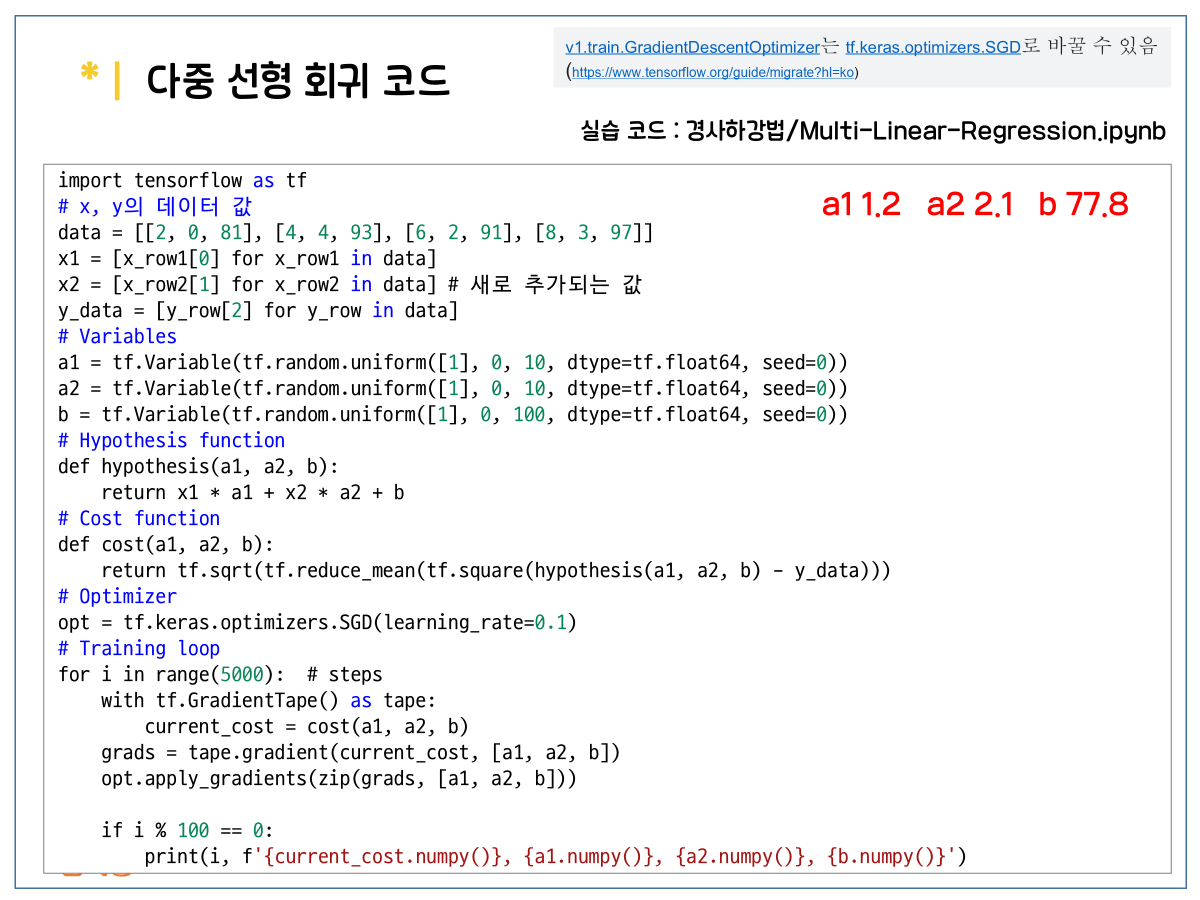

In [7]:
import tensorflow as tf

data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = [x_row1[0] for x_row1 in data]
x2 = [x_row2[1] for x_row2 in data]
y_data = [y_row[2] for y_row in data]

a1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype = tf.float64, seed = 0)) # 32비트 실수보다 더 정밀하게 표현 가능한 실수
a2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype = tf.float64, seed = 0)) 
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype = tf.float64, seed = 0))

def hypothesis(a1, a2, b):
    return x1 * a1 + x2 * a2 + b

def cost(a1, a2, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(a1, a2, b) - y_data)))

opt = tf.keras.optimizers.SGD(learning_rate = 0.1)

for i in range(5000):
    with tf.GradientTape() as tape: # tape 객체
        current_cost = cost(a1, a2, b)
    gradients = tape.gradient(current_cost, [a1, a2, b])
    opt.apply_gradients(zip(gradients, [a1, a2, b]))

    if i % 100 == 0:
        print(i, f'{current_cost.numpy()}, {a1.numpy()}, {a2.numpy()}, {b.numpy()}') # loss, w, b = tensor -> .numpy()

0 30.051348565037447, [9.34593514], [7.71024351], [41.47909885]
100 13.3932194505017, [5.96008216], [4.74700854], [44.75300997]
200 11.775554462589104, [5.62540736], [4.0223221], [48.69133315]
300 10.185877219602505, [5.13901102], [3.63240185], [52.62873801]
400 8.600476714273281, [4.59293124], [3.3747168], [56.56430966]
500 7.016068312364783, [4.02676831], [3.16180061], [60.49853071]
600 5.432781125241267, [3.45526787], [2.96122452], [64.43120282]
700 3.8519317785048792, [2.88309145], [2.76328462], [68.36078813]
800 2.2785608201992678, [2.31214431], [2.56612954], [72.2809627]
900 1.834899819187327, [2.02526032], [2.493475], [75.96389147]
1000 1.8367339006242678, [1.88375168], [2.44698957], [77.08956389]
1100 1.836959367810774, [1.81881701], [2.42496735], [77.56124922]
1200 1.8369978514930543, [1.79063986], [2.41530812], [77.75923609]
1300 1.8370046040579269, [1.7786459], [2.41117915], [77.84238363]
1400 1.8370057945891833, [1.77357958], [2.40943203], [77.8773096]
1500 1.83700600466629

```log
# v1
4900 1.8370060496869036, [1.76989908], [2.40816171], [77.90261003]

# v2
5000 1.8370060496869036, [1.76989908], [2.40816171], [77.90261003]
```





In [17]:
# 위에서 만든 모델로 예측
new_x1 = tf.constant([3, 9], dtype=tf.float64) # 공부 시간
new_x2 = tf.constant([2, 5], dtype=tf.float64) # 학원 횟수

raw_pred_scores = new_x1 * a1 + new_x2 * a2 + b # 예측 tensor 만듦
pred_scores = tf.clip_by_value(raw_pred_scores, 0, 100) # 0~100 범위로 제한 cf. 강사님 교안 모델은 100 초과하는 예측 값이 나옴
for hrs, times, pred in zip(new_x1.numpy(), new_x2.numpy(), pred_scores.numpy()):
    print(f"{hrs:.0f}시간 공부 + 학원 횟수 {times:.0f} 예상 점수 = {pred:.2f}")

3시간 공부 + 학원 횟수 2 예상 점수 = 85.83
9시간 공부 + 학원 횟수 5 예상 점수 = 99.70
